In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import os
import sys
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

### Cross-predict

Loads a model checkpoint saved by `features.ipynb` (`models.gnn.save_model`, under
`../results/models/{img_name}_{gnn|gat}.pt`) and evaluates it against a cell table --
by default the same image it was trained on (a mechanics check), but point
`EVAL_IMG_NAME` at a DIFFERENT image's `../data/training/{name}.csv` to test whether
the model actually generalizes across images, rather than just memorizing this one.

The checkpoint carries everything needed to re-apply the model correctly: the exact
`neighbor_x_cols`/`global_x_cols`/`y_cols`, the fitted scalers (REUSED, not refit --
`models.gnn.apply_prediction_data`), and the radius-graph params. Cross-image
comparisons only make sense between images sharing the same marker panel (channel
names) as whatever the model was trained on.

In [79]:
TRAIN_IMG_NAME = '20260717T120225_pA_Activin_D4_48hr_W0001'  # which saved checkpoint to load
# TRAIN_IMG_NAME = '20260521T171725_pA-BMP4_G3_44hr_induction_W0001'
MODEL_TYPE = 'gat'  # 'gnn' | 'gat' -- must match how the checkpoint was saved

EVAL_IMG_NAME = '20260717T120225_pA_Activin_D4_48hr_W00013'  # which cell table to evaluate against --
                                                              # same as TRAIN_IMG_NAME here just to check the
                                                              # mechanics; set to a DIFFERENT image (same
                                                              # marker panel) to test cross-image generalization
# PREDICT_TYPE = ''
PREDICT_TYPE = '_xActivin_ySox17' # should be '' or '_xX_yY' format
FIGURE_DIR = f'../results/figures/{TRAIN_IMG_NAME}/{PREDICT_TYPE.removeprefix("_")}/cross_predict'
os.makedirs(FIGURE_DIR, exist_ok=True) 

In [80]:
from models.gnn import load_model, apply_prediction_data, predict_df, border_mask, NeighborIFPredictor
from models.gat import NeighborIFPredictorGAT
from tools.morphology import r2_table, plot_pred_vs_actual, local_density

model_cls = NeighborIFPredictor if MODEL_TYPE == 'gnn' else NeighborIFPredictorGAT
checkpoint_path = f'../results/models/{TRAIN_IMG_NAME}{PREDICT_TYPE}_{MODEL_TYPE}.pt'
model, checkpoint = load_model(checkpoint_path, model_cls)

print(f'Loaded {checkpoint_path}')
print('neighbor_x_cols (seen only via neighbors):', checkpoint['neighbor_x_cols'])
print('global_x_cols (seen directly, incl. self):', checkpoint['global_x_cols'])
print('y_cols (predicted):', checkpoint['y_cols'])
print('radius:', checkpoint['radius'])

Loaded ../results/models/20260717T120225_pA_Activin_D4_48hr_W0001_xActivin_ySox17_gat.pt
neighbor_x_cols (seen only via neighbors): ['Activin_mean', 'local_density']
global_x_cols (seen directly, incl. self): ['Activin_mean', 'local_density']
y_cols (predicted): ['Sox17_mean']
radius: 200


In [81]:
eval_cell_df = pd.read_parquet(f'../data/stitched/{EVAL_IMG_NAME}_features.parquet')
eval_out = tiff.imread(f'../data/stitched/{EVAL_IMG_NAME}.tif')
eval_centroids = eval_cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)

all_expected_cols = set(checkpoint['global_x_cols']) | set(checkpoint['neighbor_x_cols']) | set(checkpoint['y_cols'])
needed = [c for c in all_expected_cols if c not in eval_cell_df.columns]
if 'local_density' in needed:
    density_radius = checkpoint.get('density_radius') or checkpoint['radius']
    eval_cell_df['local_density'] = local_density(eval_centroids, radius=density_radius)
    needed.remove('local_density')
if needed:
    raise ValueError(f'eval_cell_df is missing columns the checkpoint expects: {needed}')

border_radius = max(checkpoint['radius'], checkpoint.get('density_radius') or 0)
eval_is_border = border_mask(eval_centroids, eval_out.shape[1:], border_radius)
eval_mask = torch.from_numpy(~eval_is_border)
print(f"{eval_is_border.sum()} / {len(eval_cell_df)} cells within {border_radius}px of the border -- excluded from eval")

eval_data = apply_prediction_data(eval_cell_df, checkpoint)
print(f"{len(eval_cell_df)} cells, {eval_data['edge_index'].shape[1]} directed edges")

FileNotFoundError: [Errno 2] No such file or directory: '../data/stitched/20260717T120225_pA_Activin_D4_48hr_W00013_features.parquet'

,R2,MAE
feature,,
Sox17_mean,-1.598701,1.353969


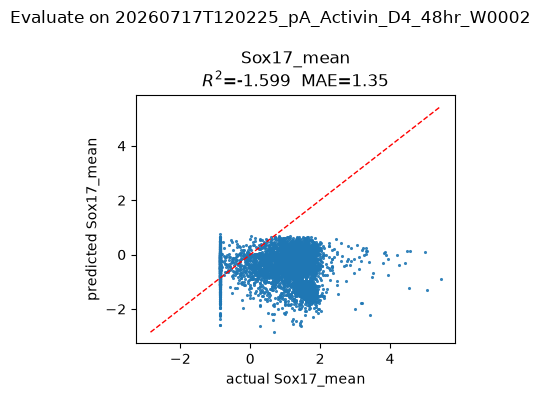

In [ ]:
pred_df, true_df = predict_df(model, eval_data, eval_mask, eval_cell_df.index, y_scaler=None)
r2 = r2_table(true_df, pred_df)
display(r2)

fig_pred  = plot_pred_vs_actual(true_df, pred_df, title=f'Evaluate on {EVAL_IMG_NAME}')
plt.show()

fig_pred.savefig(f'{FIGURE_DIR}/{MODEL_TYPE}_{EVAL_IMG_NAME}_r2.png', dpi=300, bbox_inches='tight')

In [82]:
y_cols = list(pred_df.columns)
centroids_eval = eval_cell_df.loc[pred_df.index, ['centroid_x', 'centroid_y']]

data = centroids_eval.copy()
for col in y_cols:
    data[f'{col} (actual)'] = true_df[col].values
    data[f'{col} (predicted)'] = pred_df[col].values

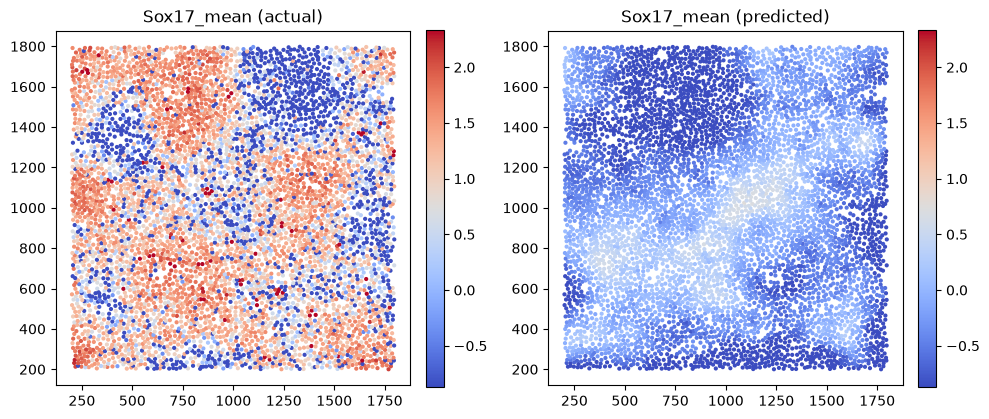

In [83]:
plot_cols = [x for x in data.columns if 'centroid' not in x]
fig, axs = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 5))
axs = axs.flatten()

for i, col in enumerate(plot_cols):
    ax = axs[i]

    base_col = col.split(' (')[0]
    vmin, vmax = np.percentile(data[f'{base_col} (actual)'], [1, 99])
    sc = ax.scatter(
        data['centroid_x'], data['centroid_y'],
        c=data[col], cmap='coolwarm',
        s=4, vmin=vmin, vmax=vmax,
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()

fig.savefig(f'{FIGURE_DIR}/{MODEL_TYPE}_{EVAL_IMG_NAME}_spatial.png', dpi=300)
plt.show()

In [84]:
data[[x for x in data.columns if 'centroid' not in x]].corr(method='spearman')

,Sox17_mean (actual),Sox17_mean (predicted)
Sox17_mean (actual),1.000000,0.043807
Sox17_mean (predicted),0.043807,1.000000
